# y=x 平行ライン上の波長スパイク検出

このノートブックは、2100–2400 nm 帯で

- ある波長だけが左右の隣接波長より大きい
- 異常ピクセルが画像上で `y=x` と平行な斜め直線になる
- 直線は複数あり、直線ごとに異常波長が異なる可能性がある

という前提に合わせて整理した版です。

ポイントは、先に **波長方向の局所ピーク量** を計算し、その後で **`row - col` ごとに集約** することです。  
`row - col` が一定の画素群は、画像上で `y=x` と平行な直線になります。


In [3]:

from __future__ import annotations

import re
from pathlib import Path
from typing import Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# CONFIG
# ============================================================

CSV_PATH = r"D:\research\code\all_roi_spectra200x200.csv"
OUT_DIR = r"D:\research\code\diagonal_spike_check"

# User-described target range
WL_MIN = 2100.0
WL_MAX = 2400.0
EXCLUDE_RANGES: Optional[Sequence[Tuple[float, float]]] = None

# Adjacent-band spike definition:
# center band is compared with center-neighbor_offset and center+neighbor_offset.
NEIGHBOR_OFFSET = 1

# Pixel-level spike threshold.
# Raise this if many false positive pixels appear.
PIXEL_Z_THRESHOLD = 4.0

# Line-level criteria.
# Because the artifact is known to form y=x-parallel lines, we aggregate spike pixels
# by diagonal id = row - col.
MIN_LINE_PIXELS = 20       # ignore very short diagonals near image corners
MIN_HIT_PIXELS = 6         # at least this many spike pixels on one diagonal/wavelength
MIN_HIT_FRACTION = 0.10    # fraction of valid pixels on the diagonal that are spike pixels
LINE_PERCENTILE = 80.0     # percentile of spike_z along a diagonal
LINE_SCORE_THRESHOLD = 2.5 # required percentile score

# If True, keep only the strongest wavelength candidate within +/- BAND_SEPARATION bands
# for each diagonal. Useful when the same one-band artifact leaks into neighboring bands.
COLLAPSE_ADJACENT_BANDS = True
BAND_SEPARATION = 2

# Diagonal definition:
# "row_col": diagonal id = row - col. Recommended for regular image grids.
# "coord":   diagonal id = y - x. Use this if raw CSV coordinates are guaranteed regular.
DIAG_MODE = "row_col"

REQUIRE_POSITIVE = True


# ============================================================
# Loading and cube construction
# ============================================================

def get_wave_columns(df: pd.DataFrame) -> tuple[list[str], np.ndarray]:
    """Find columns like wave_2300.00nm and return them sorted by wavelength."""
    wave_cols: list[str] = []
    wavelengths: list[float] = []
    pattern = re.compile(r"^wave_([0-9]+(?:\.[0-9]+)?)nm$")

    for col in df.columns:
        m = pattern.match(str(col))
        if m is not None:
            wave_cols.append(col)
            wavelengths.append(float(m.group(1)))

    if len(wave_cols) == 0:
        raise ValueError("No wavelength columns found. Expected columns like wave_2300.00nm.")

    wavelengths_arr = np.asarray(wavelengths, dtype=float)
    order = np.argsort(wavelengths_arr)
    wavelengths_arr = wavelengths_arr[order]
    wave_cols = [wave_cols[i] for i in order]
    return wave_cols, wavelengths_arr


def load_roi_spectra_csv(path: str | Path) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, list[str]]:
    """Load ROI spectra CSV containing y, x, and wave_****nm columns."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path}")

    df = pd.read_csv(path)

    if "y" not in df.columns or "x" not in df.columns:
        raise ValueError("The CSV must contain 'y' and 'x' columns.")

    wave_cols, wavelengths = get_wave_columns(df)
    spectra = df[wave_cols].to_numpy(dtype=float)
    return df, wavelengths, spectra, wave_cols


def spectra_to_cube(
    df: pd.DataFrame,
    spectra: np.ndarray,
    fill_value: float = np.nan,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert table spectra to cube[H, W, B].

    Returns
    -------
    cube : ndarray
        cube[row, col, band]
    ys : ndarray
        ys[row] gives original CSV y coordinate
    xs : ndarray
        xs[col] gives original CSV x coordinate
    """
    ys = np.sort(df["y"].unique())
    xs = np.sort(df["x"].unique())

    y_to_row = {y: i for i, y in enumerate(ys)}
    x_to_col = {x: j for j, x in enumerate(xs)}

    H, W = len(ys), len(xs)
    B = spectra.shape[1]
    cube = np.full((H, W, B), fill_value, dtype=float)

    # Keep this simple and safe. 200x200 is fine with iterrows.
    for row_idx, row in df.iterrows():
        r = y_to_row[row["y"]]
        c = x_to_col[row["x"]]
        cube[r, c, :] = spectra[row_idx, :]

    return cube, ys, xs


def band_mask(
    wavelengths: np.ndarray,
    wl_min: Optional[float] = None,
    wl_max: Optional[float] = None,
    exclude_ranges: Optional[Sequence[Tuple[float, float]]] = None,
) -> np.ndarray:
    """Create wavelength selection mask."""
    mask = np.ones_like(wavelengths, dtype=bool)
    if wl_min is not None:
        mask &= wavelengths >= wl_min
    if wl_max is not None:
        mask &= wavelengths <= wl_max
    if exclude_ranges is not None:
        for a, b in exclude_ranges:
            mask &= ~((wavelengths >= a) & (wavelengths <= b))
    return mask


def make_valid_mask(cube: np.ndarray, require_positive: bool = True) -> np.ndarray:
    """Valid if all selected-band values are finite and optionally positive."""
    valid = np.all(np.isfinite(cube), axis=2)
    if require_positive:
        valid &= np.all(cube > 0, axis=2)
    return valid


# ============================================================
# Spectral one-band spike score
# ============================================================

def robust_z_by_band(
    values: np.ndarray,
    valid3: np.ndarray,
    eps: float = 1e-12,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Robust z-score for values[H, W, B] independently for each band.
    z = (value - median_band) / (1.4826 * MAD_band)
    """
    masked = np.where(valid3, values, np.nan)
    med = np.nanmedian(masked, axis=(0, 1))
    mad = np.nanmedian(np.abs(masked - med[None, None, :]), axis=(0, 1))
    scale = 1.4826 * mad + eps
    z = (values - med[None, None, :]) / scale[None, None, :]
    z[~valid3] = np.nan
    return z, med, scale


def compute_spectral_spike_cube(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    valid_mask: np.ndarray,
    neighbor_offset: int = 1,
) -> dict:
    """
    Compute how much each center band sticks out above its adjacent bands.

    For each center band b:
        baseline = 0.5 * (spectrum[b-k] + spectrum[b+k])
        spike_height = spectrum[b] - baseline

    This directly encodes the user's error definition:
    "a spectrum at a certain wavelength is larger than its neighboring wavelengths."
    """
    if neighbor_offset < 1:
        raise ValueError("neighbor_offset must be >= 1.")

    H, W, B = cube.shape
    k = neighbor_offset
    if B <= 2 * k:
        raise ValueError("Not enough bands for the requested neighbor_offset.")

    left = cube[:, :, 0:B - 2 * k]
    center = cube[:, :, k:B - k]
    right = cube[:, :, 2 * k:B]

    center_wavelengths = wavelengths[k:B - k]
    center_band_indices = np.arange(k, B - k)

    local_baseline = 0.5 * (left + right)
    spike_height = center - local_baseline
    spike_ratio = center / np.maximum(local_baseline, 1e-12)
    is_local_peak = (center > left) & (center > right)

    valid3 = (
        valid_mask[:, :, None]
        & np.isfinite(left)
        & np.isfinite(center)
        & np.isfinite(right)
        & np.isfinite(spike_height)
    )

    spike_z, spike_med, spike_scale = robust_z_by_band(spike_height, valid3)

    return {
        "left": left,
        "center": center,
        "right": right,
        "local_baseline": local_baseline,
        "spike_height": spike_height,
        "spike_ratio": spike_ratio,
        "spike_z": spike_z,
        "is_local_peak": is_local_peak,
        "valid3": valid3,
        "center_wavelengths": center_wavelengths,
        "center_band_indices": center_band_indices,
        "spike_median_by_band": spike_med,
        "spike_scale_by_band": spike_scale,
    }


# ============================================================
# Diagonal line aggregation
# ============================================================

def make_diagonal_id_map(
    H: int,
    W: int,
    ys: np.ndarray,
    xs: np.ndarray,
    mode: str = "row_col",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Create diagonal ids for y=x-parallel lines.

    row_col mode:
        diag_id = row - col
        robust if the image grid is regular.

    coord mode:
        diag_id = y - x
        matches raw coordinate equation directly if y and x have the same spacing.
    """
    rr, cc = np.indices((H, W))

    if mode == "row_col":
        diag_id = rr - cc
    elif mode == "coord":
        diag_id = ys[rr] - xs[cc]
    else:
        raise ValueError("mode must be 'row_col' or 'coord'.")

    y_minus_x = ys[rr] - xs[cc]
    return diag_id, y_minus_x


def collapse_adjacent_band_candidates(
    df_lines: pd.DataFrame,
    band_separation: int = 2,
) -> pd.DataFrame:
    """
    For each diagonal, keep only the strongest candidates that are separated
    by more than band_separation in center-band index.
    """
    if len(df_lines) == 0:
        return df_lines

    kept = []
    sort_cols = ["diag_id", "line_score", "hit_fraction", "n_hit"]
    df_sorted = df_lines.sort_values(sort_cols, ascending=[True, False, False, False])

    for diag_id, g in df_sorted.groupby("diag_id", sort=False):
        selected_band_indices = []
        for _, row in g.iterrows():
            b = int(row["center_band_index"])
            if all(abs(b - sb) > band_separation for sb in selected_band_indices):
                kept.append(row)
                selected_band_indices.append(b)

    out = pd.DataFrame(kept)
    out = out.sort_values(["line_score", "n_hit"], ascending=False).reset_index(drop=True)
    return out


def detect_diagonal_spike_lines(
    spike: dict,
    valid_mask: np.ndarray,
    ys: np.ndarray,
    xs: np.ndarray,
    diag_mode: str = "row_col",
    pixel_z_threshold: float = 5.0,
    min_line_pixels: int = 20,
    min_hit_pixels: int = 6,
    min_hit_fraction: float = 0.20,
    line_percentile: float = 80.0,
    line_score_threshold: float = 3.0,
    collapse_adjacent_bands: bool = True,
    band_separation: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    Detect diagonal line artifacts and their wavelengths.

    Returns
    -------
    df_lines : DataFrame
        One row per detected diagonal/wavelength pair.
    df_pixels : DataFrame
        One row per detected anomalous pixel.
    maps : dict
        Useful 2D maps for visualization/export.
    """
    spike_z = spike["spike_z"]
    spike_height = spike["spike_height"]
    is_local_peak = spike["is_local_peak"]
    center_wavelengths = spike["center_wavelengths"]
    center_band_indices = spike["center_band_indices"]
    center = spike["center"]
    left = spike["left"]
    right = spike["right"]
    baseline = spike["local_baseline"]

    H, W, Bc = spike_z.shape
    diag_id_map, y_minus_x_map = make_diagonal_id_map(H, W, ys, xs, mode=diag_mode)

    line_rows = []
    unique_diags = np.unique(diag_id_map[valid_mask])

    for diag_id in unique_diags:
        diag_mask = (diag_id_map == diag_id) & valid_mask
        n_valid = int(np.sum(diag_mask))
        if n_valid < min_line_pixels:
            continue

        for kb in range(Bc):
            z_vals = spike_z[:, :, kb][diag_mask]
            peak_vals = is_local_peak[:, :, kb][diag_mask]
            finite = np.isfinite(z_vals)
            if np.sum(finite) < min_line_pixels:
                continue

            hit_vals = finite & peak_vals & (z_vals >= pixel_z_threshold)
            n_hit = int(np.sum(hit_vals))
            hit_fraction = n_hit / max(1, int(np.sum(finite)))

            if n_hit == 0:
                max_z = float(np.nanmax(z_vals[finite])) if np.any(finite) else np.nan
            else:
                max_z = float(np.nanmax(z_vals[hit_vals]))

            p_score = float(np.nanpercentile(z_vals[finite], line_percentile))
            median_z = float(np.nanmedian(z_vals[finite]))

            if (
                n_hit >= min_hit_pixels
                and hit_fraction >= min_hit_fraction
                and p_score >= line_score_threshold
            ):
                line_rows.append({
                    "diag_id": diag_id,
                    "diag_mode": diag_mode,
                    "center_band_index": int(center_band_indices[kb]),
                    "center_wavelength_nm": float(center_wavelengths[kb]),
                    "n_valid_on_line": int(np.sum(finite)),
                    "n_hit": n_hit,
                    "hit_fraction": float(hit_fraction),
                    "line_score": p_score,
                    "line_percentile": line_percentile,
                    "median_z_on_line": median_z,
                    "max_z_on_line": max_z,
                })

    df_lines = pd.DataFrame(line_rows)

    if len(df_lines) > 0:
        df_lines = df_lines.sort_values(
            ["line_score", "hit_fraction", "n_hit"],
            ascending=False
        ).reset_index(drop=True)

        if collapse_adjacent_bands:
            df_lines = collapse_adjacent_band_candidates(df_lines, band_separation=band_separation)

    # Pixel table and maps for accepted line/wavelength pairs
    rr_grid, cc_grid = np.indices((H, W))
    detected_mask = np.zeros((H, W), dtype=bool)
    best_z_map = np.full((H, W), np.nan, dtype=float)
    wavelength_map = np.full((H, W), np.nan, dtype=float)
    diag_map_out = np.full((H, W), np.nan, dtype=float)

    pixel_rows = []

    for line_idx, line in df_lines.iterrows():
        diag_id = line["diag_id"]
        center_band_index = int(line["center_band_index"])
        # Convert original selected-band index to spike-cube index.
        kb_matches = np.where(center_band_indices == center_band_index)[0]
        if len(kb_matches) == 0:
            continue
        kb = int(kb_matches[0])

        hit_mask = (
            (diag_id_map == diag_id)
            & valid_mask
            & is_local_peak[:, :, kb]
            & np.isfinite(spike_z[:, :, kb])
            & (spike_z[:, :, kb] >= pixel_z_threshold)
        )

        rows, cols = np.where(hit_mask)

        for r, c in zip(rows, cols):
            z_val = float(spike_z[r, c, kb])
            detected_mask[r, c] = True

            if not np.isfinite(best_z_map[r, c]) or z_val > best_z_map[r, c]:
                best_z_map[r, c] = z_val
                wavelength_map[r, c] = float(center_wavelengths[kb])
                diag_map_out[r, c] = float(diag_id)

            pixel_rows.append({
                "line_rank": int(line_idx),
                "row": int(r),
                "col": int(c),
                "y": ys[r],
                "x": xs[c],
                "diag_id": diag_id,
                "y_minus_x": y_minus_x_map[r, c],
                "center_band_index": int(center_band_indices[kb]),
                "center_wavelength_nm": float(center_wavelengths[kb]),
                "spike_z": z_val,
                "spike_height": float(spike_height[r, c, kb]),
                "left_value": float(left[r, c, kb]),
                "center_value": float(center[r, c, kb]),
                "right_value": float(right[r, c, kb]),
                "local_baseline": float(baseline[r, c, kb]),
            })

    df_pixels = pd.DataFrame(pixel_rows)
    if len(df_pixels) > 0:
        df_pixels = df_pixels.sort_values(
            ["line_rank", "diag_id", "center_wavelength_nm", "row", "col"]
        ).reset_index(drop=True)

    max_spike_z_map = np.nanmax(spike_z, axis=2)

    maps = {
        "detected_mask": detected_mask,
        "best_z_map": best_z_map,
        "wavelength_map": wavelength_map,
        "diag_id_map": diag_id_map,
        "detected_diag_map": diag_map_out,
        "max_spike_z_map": max_spike_z_map,
        "y_minus_x_map": y_minus_x_map,
    }

    return df_lines, df_pixels, maps


# ============================================================
# Plotting / exporting
# ============================================================

def save_map_csv(arr: np.ndarray, path: str | Path) -> None:
    path = Path(path)
    pd.DataFrame(arr).to_csv(path, index=False, header=False)
    print(f"Saved: {path}")


def plot_map(
    arr: np.ndarray,
    title: str,
    out_png: str | Path,
    colorbar_label: str = "value",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
) -> None:
    plt.figure(figsize=(7, 6))
    im = plt.imshow(arr, origin="upper", vmin=vmin, vmax=vmax)
    plt.colorbar(im, label=colorbar_label)
    plt.xlabel("x / col")
    plt.ylabel("y / row")
    plt.title(title)
    plt.tight_layout()
    out_png = Path(out_png)
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved: {out_png}")


def plot_detected_overlay(
    base_map: np.ndarray,
    detected_mask: np.ndarray,
    out_png: str | Path,
    title: str = "Detected diagonal spike pixels",
) -> None:
    finite = base_map[np.isfinite(base_map)]
    vmin = np.nanpercentile(finite, 2) if finite.size else None
    vmax = np.nanpercentile(finite, 98) if finite.size else None

    plt.figure(figsize=(7, 6))
    plt.imshow(base_map, origin="upper", vmin=vmin, vmax=vmax)
    yy, xx = np.where(detected_mask)
    plt.scatter(xx, yy, s=8, facecolors="none", edgecolors="red", linewidths=0.7)
    plt.colorbar(label="max spectral spike z-score")
    plt.xlabel("x / col")
    plt.ylabel("y / row")
    plt.title(title)
    plt.tight_layout()
    out_png = Path(out_png)
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved: {out_png}")


def plot_line_spectrum_examples(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    df_pixels: pd.DataFrame,
    out_dir: str | Path,
    max_examples: int = 10,
) -> None:
    """Plot spectra for the strongest detected pixels."""
    if len(df_pixels) == 0:
        print("No detected pixels to plot.")
        return

    out_dir = Path(out_dir)
    examples = df_pixels.sort_values("spike_z", ascending=False).head(max_examples)

    for _, row in examples.iterrows():
        r = int(row["row"])
        c = int(row["col"])
        wl = float(row["center_wavelength_nm"])
        spec = cube[r, c, :]

        plt.figure(figsize=(9, 4))
        plt.plot(wavelengths, spec, marker="o", linewidth=1)
        plt.axvline(wl, linestyle="--", linewidth=1)
        plt.xlabel("Wavelength [nm]")
        plt.ylabel("Radiance / Reflectance")
        plt.title(f"Detected spike: y={row['y']}, x={row['x']}, wl={wl:.2f} nm, z={row['spike_z']:.2f}")
        plt.grid(True)
        plt.tight_layout()

        out_png = out_dir / f"spectrum_y{row['y']}_x{row['x']}_wl{wl:.2f}.png".replace(".", "p")
        plt.savefig(out_png, dpi=200)
        plt.show()
        print(f"Saved: {out_png}")


# ============================================================
# Main runner
# ============================================================

def run_detector(
    csv_path: str | Path = CSV_PATH,
    out_dir: str | Path = OUT_DIR,
) -> dict:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    print("Loading CSV...")
    df, wavelengths_all, spectra_all, wave_cols_all = load_roi_spectra_csv(csv_path)
    cube_all, ys, xs = spectra_to_cube(df, spectra_all)

    print(f"CSV rows: {len(df)}")
    print(f"Cube shape: {cube_all.shape}")
    print(f"Original y range: {ys[0]} to {ys[-1]}")
    print(f"Original x range: {xs[0]} to {xs[-1]}")
    print(f"Wavelength range: {wavelengths_all[0]:.2f} to {wavelengths_all[-1]:.2f} nm")

    bmask = band_mask(wavelengths_all, WL_MIN, WL_MAX, EXCLUDE_RANGES)
    cube = cube_all[:, :, bmask]
    wavelengths = wavelengths_all[bmask]

    if cube.shape[2] == 0:
        raise ValueError("No bands selected. Check WL_MIN/WL_MAX/EXCLUDE_RANGES.")

    print(f"Selected wavelength range: {wavelengths[0]:.2f} to {wavelengths[-1]:.2f} nm")
    print(f"Selected bands: {cube.shape[2]}")

    valid_mask = make_valid_mask(cube, require_positive=REQUIRE_POSITIVE)
    print(f"Valid pixels: {np.sum(valid_mask)} / {valid_mask.size}")

    print("Computing spectral one-band spike score...")
    spike = compute_spectral_spike_cube(
        cube=cube,
        wavelengths=wavelengths,
        valid_mask=valid_mask,
        neighbor_offset=NEIGHBOR_OFFSET,
    )

    print("Aggregating by y=x-parallel diagonals...")
    df_lines, df_pixels, maps = detect_diagonal_spike_lines(
        spike=spike,
        valid_mask=valid_mask,
        ys=ys,
        xs=xs,
        diag_mode=DIAG_MODE,
        pixel_z_threshold=PIXEL_Z_THRESHOLD,
        min_line_pixels=MIN_LINE_PIXELS,
        min_hit_pixels=MIN_HIT_PIXELS,
        min_hit_fraction=MIN_HIT_FRACTION,
        line_percentile=LINE_PERCENTILE,
        line_score_threshold=LINE_SCORE_THRESHOLD,
        collapse_adjacent_bands=COLLAPSE_ADJACENT_BANDS,
        band_separation=BAND_SEPARATION,
    )

    print(f"Detected line/wavelength pairs: {len(df_lines)}")
    print(f"Detected pixels: {len(df_pixels)}")

    # Save outputs
    df_lines.to_csv(out_dir / "detected_diagonal_lines.csv", index=False)
    df_pixels.to_csv(out_dir / "detected_anomaly_pixels.csv", index=False)
    print(f"Saved: {out_dir / 'detected_diagonal_lines.csv'}")
    print(f"Saved: {out_dir / 'detected_anomaly_pixels.csv'}")

    save_map_csv(maps["detected_mask"].astype(int), out_dir / "detected_mask.csv")
    save_map_csv(maps["best_z_map"], out_dir / "detected_best_spike_z_map.csv")
    save_map_csv(maps["wavelength_map"], out_dir / "detected_wavelength_map.csv")
    save_map_csv(maps["max_spike_z_map"], out_dir / "max_spike_z_map.csv")

    finite = maps["max_spike_z_map"][np.isfinite(maps["max_spike_z_map"])]
    vmax = np.nanpercentile(finite, 99) if finite.size else None

    plot_map(
        maps["max_spike_z_map"],
        title="Maximum spectral one-band spike z-score",
        out_png=out_dir / "max_spike_z_map.png",
        colorbar_label="max spike z",
        vmin=0,
        vmax=vmax,
    )

    plot_map(
        maps["wavelength_map"],
        title="Detected artifact wavelength map",
        out_png=out_dir / "detected_wavelength_map.png",
        colorbar_label="wavelength [nm]",
    )

    plot_detected_overlay(
        base_map=maps["max_spike_z_map"],
        detected_mask=maps["detected_mask"],
        out_png=out_dir / "detected_overlay.png",
    )

    plot_line_spectrum_examples(
        cube=cube,
        wavelengths=wavelengths,
        df_pixels=df_pixels,
        out_dir=out_dir,
        max_examples=10,
    )

    return {
        "df": df,
        "cube": cube,
        "wavelengths": wavelengths,
        "ys": ys,
        "xs": xs,
        "valid_mask": valid_mask,
        "spike": spike,
        "df_lines": df_lines,
        "df_pixels": df_pixels,
        "maps": maps,
        "out_dir": out_dir,
    }


## 出力ファイル

`OUT_DIR` に主に以下が保存されます。

- `detected_diagonal_lines.csv`  
  検出された「斜め直線 × 異常波長」の一覧
- `detected_anomaly_pixels.csv`  
  検出された異常ピクセル一覧
- `detected_mask.csv`  
  異常ピクセルマスク
- `detected_wavelength_map.csv`  
  各異常ピクセルの推定異常波長
- `max_spike_z_map.png`, `detected_wavelength_map.png`, `detected_overlay.png`  
  確認用画像

検出されすぎる場合は `PIXEL_Z_THRESHOLD`, `MIN_HIT_FRACTION`, `LINE_SCORE_THRESHOLD` を上げてください。  
検出されなさすぎる場合はそれらを下げてください。


Loading CSV...
CSV rows: 40000
Cube shape: (200, 200, 185)
Original y range: 0 to 199
Original x range: 0 to 199
Wavelength range: 405.00 to 2474.76 nm
Selected wavelength range: 2100.05 to 2399.82 nm
Selected bands: 25
Valid pixels: 40000 / 40000
Computing spectral one-band spike score...
Aggregating by y=x-parallel diagonals...
Detected line/wavelength pairs: 40
Detected pixels: 913
Saved: D:\research\code\diagonal_spike_check\detected_diagonal_lines.csv
Saved: D:\research\code\diagonal_spike_check\detected_anomaly_pixels.csv
Saved: D:\research\code\diagonal_spike_check\detected_mask.csv
Saved: D:\research\code\diagonal_spike_check\detected_best_spike_z_map.csv
Saved: D:\research\code\diagonal_spike_check\detected_wavelength_map.csv
Saved: D:\research\code\diagonal_spike_check\max_spike_z_map.csv


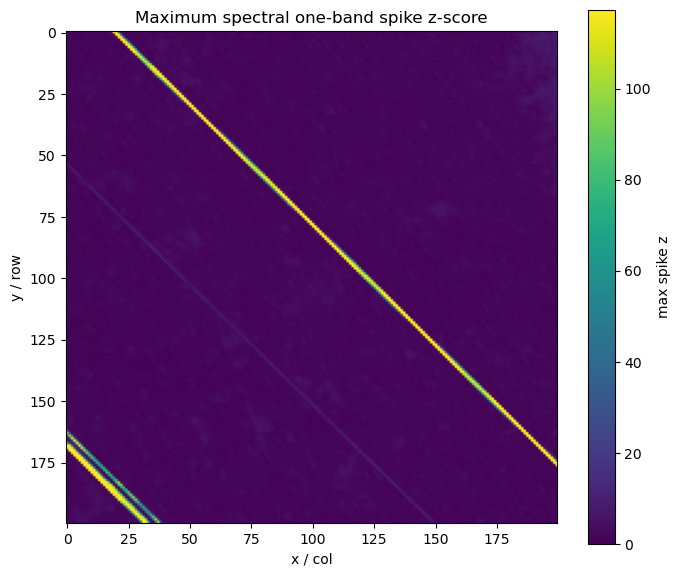

Saved: D:\research\code\diagonal_spike_check\max_spike_z_map.png


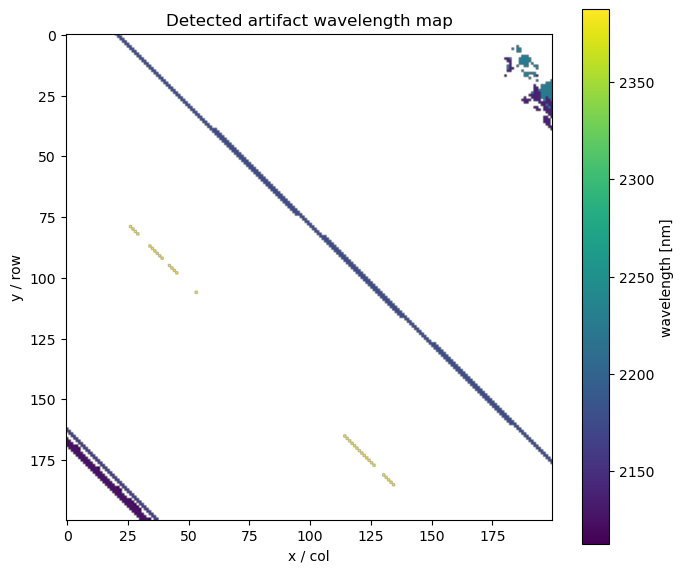

Saved: D:\research\code\diagonal_spike_check\detected_wavelength_map.png


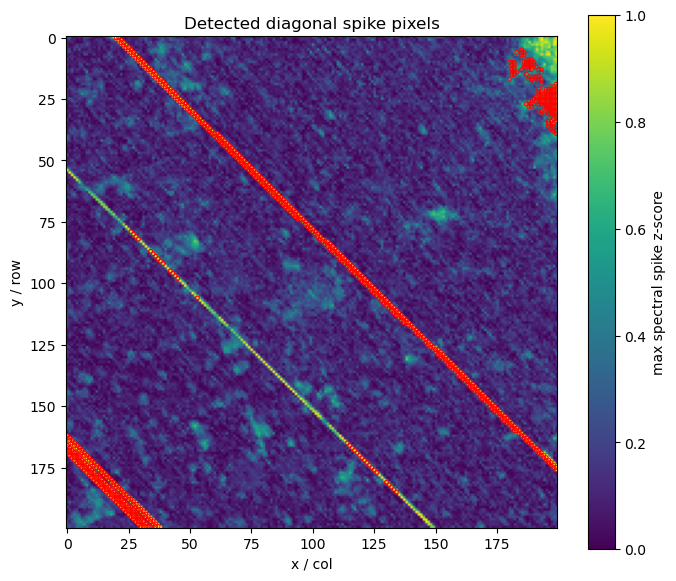

Saved: D:\research\code\diagonal_spike_check\detected_overlay.png


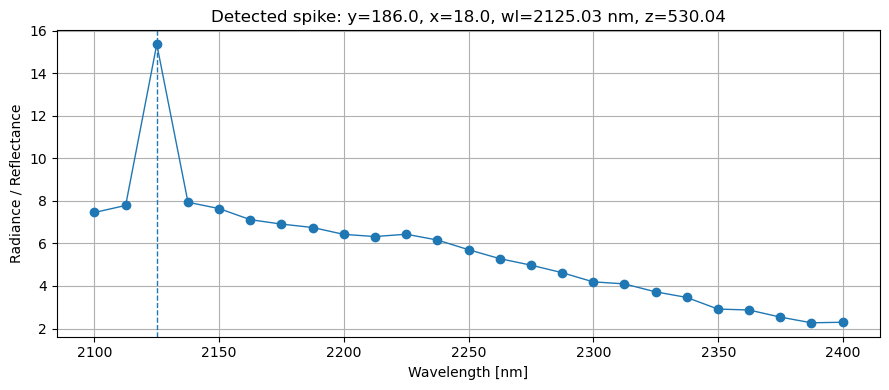

Saved: D:\research\code\diagonal_spike_check\spectrum_y186p0_x18p0_wl2125p03ppng


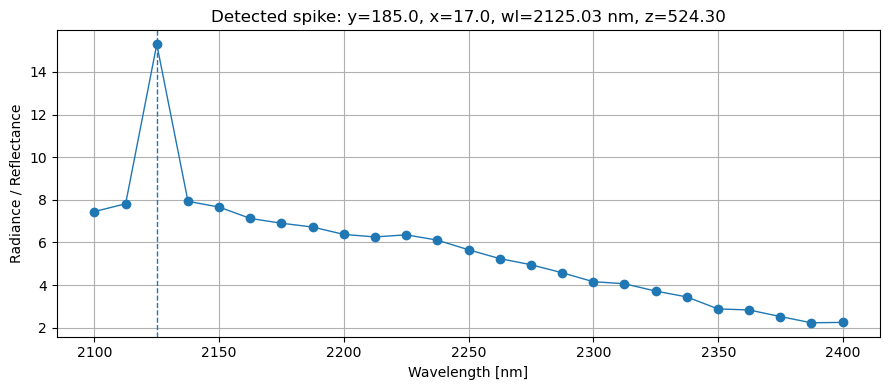

Saved: D:\research\code\diagonal_spike_check\spectrum_y185p0_x17p0_wl2125p03ppng


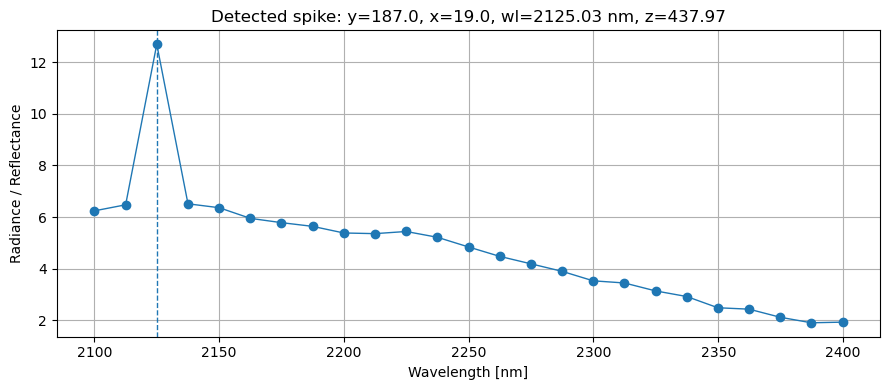

Saved: D:\research\code\diagonal_spike_check\spectrum_y187p0_x19p0_wl2125p03ppng


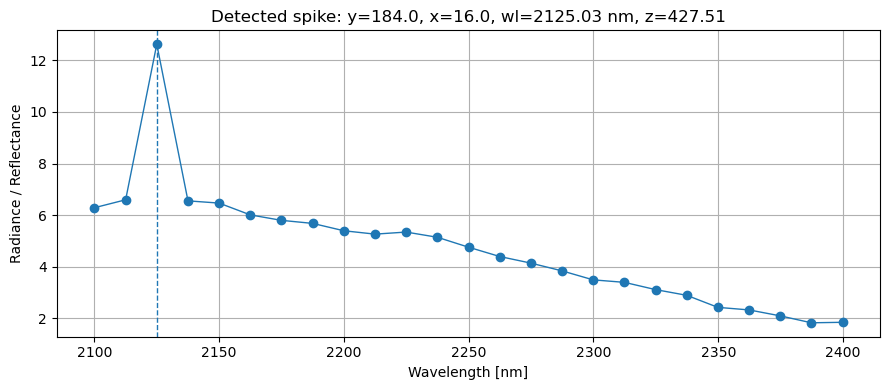

Saved: D:\research\code\diagonal_spike_check\spectrum_y184p0_x16p0_wl2125p03ppng


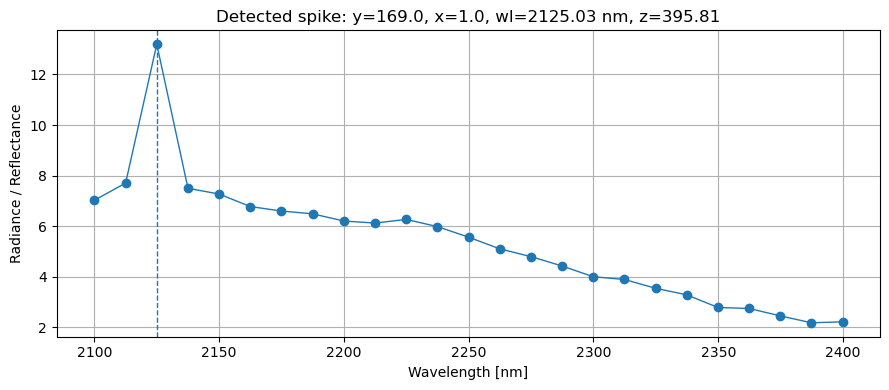

Saved: D:\research\code\diagonal_spike_check\spectrum_y169p0_x1p0_wl2125p03ppng


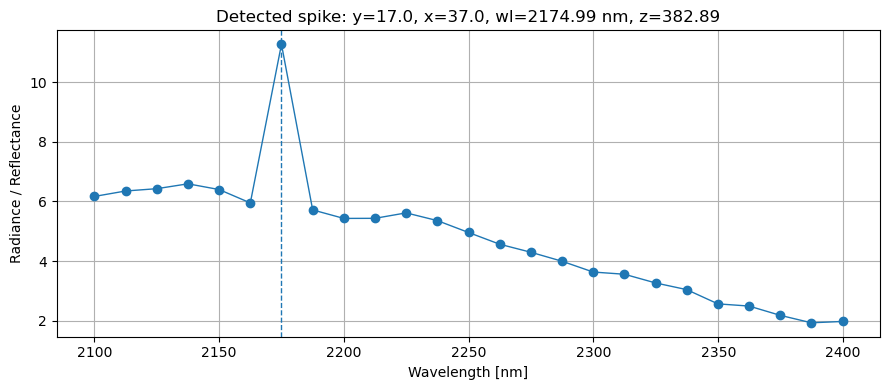

Saved: D:\research\code\diagonal_spike_check\spectrum_y17p0_x37p0_wl2174p99ppng


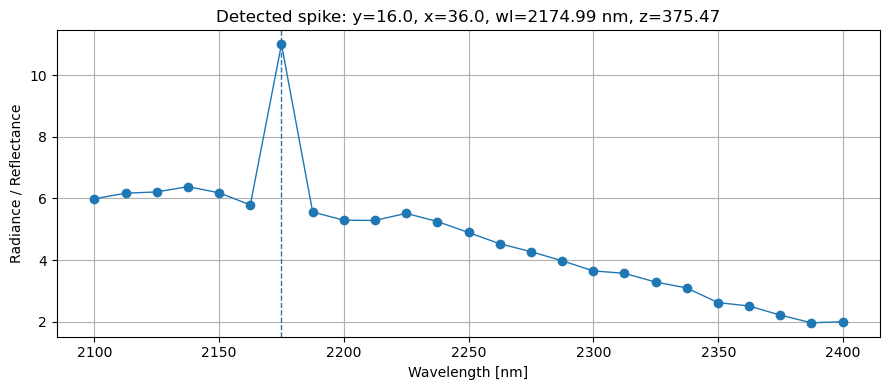

Saved: D:\research\code\diagonal_spike_check\spectrum_y16p0_x36p0_wl2174p99ppng


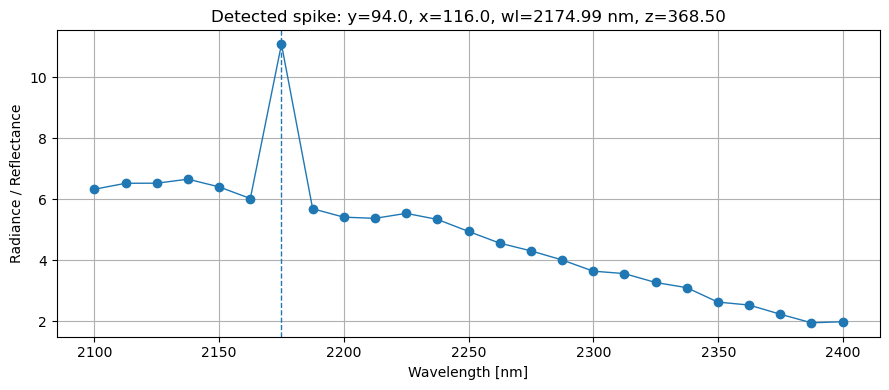

Saved: D:\research\code\diagonal_spike_check\spectrum_y94p0_x116p0_wl2174p99ppng


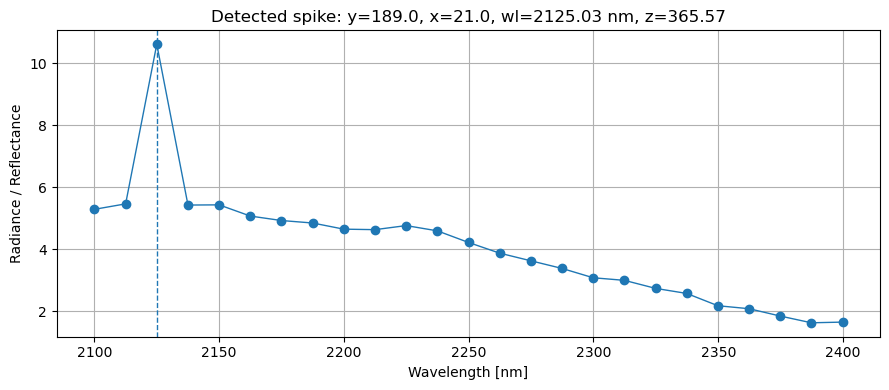

Saved: D:\research\code\diagonal_spike_check\spectrum_y189p0_x21p0_wl2125p03ppng


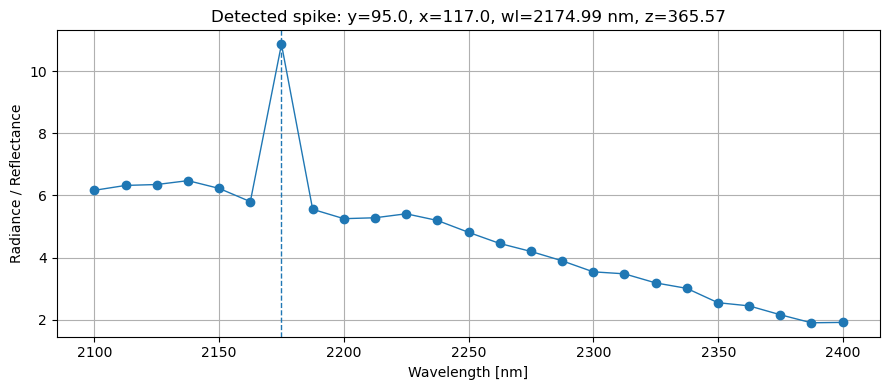

Saved: D:\research\code\diagonal_spike_check\spectrum_y95p0_x117p0_wl2174p99ppng


,diag_id,diag_mode,center_band_index,center_wavelength_nm,n_valid_on_line,n_hit,hit_fraction,line_score,line_percentile,median_z_on_line,max_z_on_line
0,168,row_col,2,2125.03,32,32,1.000000,364.045146,80.0,301.160124,530.037322
1,-23,row_col,6,2174.99,177,94,0.531073,243.176402,80.0,38.333558,322.968659
2,-21,row_col,6,2174.99,179,117,0.653631,217.096092,80.0,78.353343,303.071181
3,-22,row_col,6,2174.99,178,122,0.685393,213.768605,80.0,83.974100,368.496785
4,-20,row_col,6,2174.99,180,75,0.416667,202.841854,80.0,1.348982,382.885921
5,167,row_col,2,2125.03,33,33,1.000000,201.133144,80.0,173.681371,278.002608
6,169,row_col,2,2125.03,31,31,1.000000,180.089033,80.0,149.062458,319.708620
7,163,row_col,5,2162.51,37,37,1.000000,91.949953,80.0,72.170511,120.396601
8,162,row_col,5,2162.51,38,38,1.000000,88.678673,80.0,66.521651,105.895049
9,166,row_col,2,2125.03,34,34,1.000000,85.210666,80.0,68.404605,100.948784


,line_rank,row,col,y,x,diag_id,y_minus_x,center_band_index,center_wavelength_nm,spike_z,spike_height,left_value,center_value,right_value,local_baseline
0,0,168,0,168,0,168,168,2,2125.03,308.916768,4.3616,6.6240,10.8448,6.3424,6.4832
1,0,169,1,169,1,168,168,2,2125.03,395.813661,5.5984,7.7024,13.1968,7.4944,7.5984
2,0,170,2,170,2,168,168,2,2125.03,342.416476,4.8384,6.4000,11.1328,6.1888,6.2944
3,0,171,3,171,3,168,168,2,2125.03,250.460902,3.5296,4.6912,8.0992,4.4480,4.5696
4,0,172,4,172,4,168,168,2,2125.03,242.142183,3.4112,4.5792,7.8656,4.3296,4.4544
5,0,173,5,173,5,168,168,2,2125.03,281.824722,3.9760,5.2352,9.0816,4.9760,5.1056
6,0,174,6,174,6,168,168,2,2125.03,294.190386,4.1520,5.2992,9.3312,5.0592,5.1792
7,0,175,7,175,7,168,168,2,2125.03,276.766042,3.9040,4.9120,8.7040,4.6880,4.8000
8,0,176,8,176,8,168,168,2,2125.03,270.583210,3.8160,4.8064,8.5024,4.5664,4.6864
9,0,177,9,177,9,168,168,2,2125.03,298.462161,4.2128,5.2640,9.3632,5.0368,5.1504


In [4]:

# 実行
# CSV_PATH と OUT_DIR を自分の環境に合わせてから実行してください。

result = run_detector(
    csv_path=CSV_PATH,
    out_dir=OUT_DIR,
)

display(result["df_lines"].head(30))
display(result["df_pixels"].head(30))
